# Music Recommendation — SVD
**CSCI 4022 Final Project**

Dataset: [Spotify Playlists (andrewmvd)](https://www.kaggle.com/datasets/andrewmvd/spotify-playlists)
Columns: `user_id`, `artistname`, `trackname`, `playlistname`

### Pipeline
1. Build a **playlist x song** binary matrix
2. Hold out 20% of songs per playlist (train/test split)
3. Decompose with **SVD**, reconstruct predicted scores
4. Recommend highest-scoring absent songs
5. Evaluate with **Precision@k**, **Recall@k**, **F1@k**

## 0. Install & Import

In [1]:
# Run this cell first — installs any missing packages
# !pip install kaggle -q
# To download via Kaggle API:
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d andrewmvd/spotify-playlists && unzip -q spotify-playlists.zip

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Libraries loaded!')

Libraries loaded!


## 1. Load & Clean Data

In [3]:
# Load the dataset — update filename if needed
df = pd.read_csv('spotify_dataset.csv', encoding='utf-8', on_bad_lines='skip')

print('Raw shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Raw shape: (12891680, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']


,user_id,"""artistname""","""trackname""","""playlistname"""
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [4]:
# Clean missing/placeholder values
# Clean column names first
df.columns = df.columns.str.strip().str.replace('"', '')

df = df.dropna(subset=['trackname', 'playlistname', 'artistname'])
df = df[df['trackname'] != 'Not Specified']
df = df[df['artistname'] != 'Not Specified']

# Unique song ID = 'Artist - Track'
df['song_id'] = df['artistname'].str.strip() + ' - ' + df['trackname'].str.strip()

print(f'Cleaned shape:      {df.shape}')
print(f'Unique playlists:   {df["playlistname"].nunique():,}')
print(f'Unique songs:       {df["song_id"].nunique():,}')
print(f'Unique users:       {df["user_id"].nunique():,}')

Cleaned shape:      (12856831, 5)
Unique playlists:   157,320
Unique songs:       2,789,536
Unique users:       15,914


## 2. EDA — Figure 1: Playlist Size Distribution
Understanding how many songs are in each playlist shows us the density we are working with.

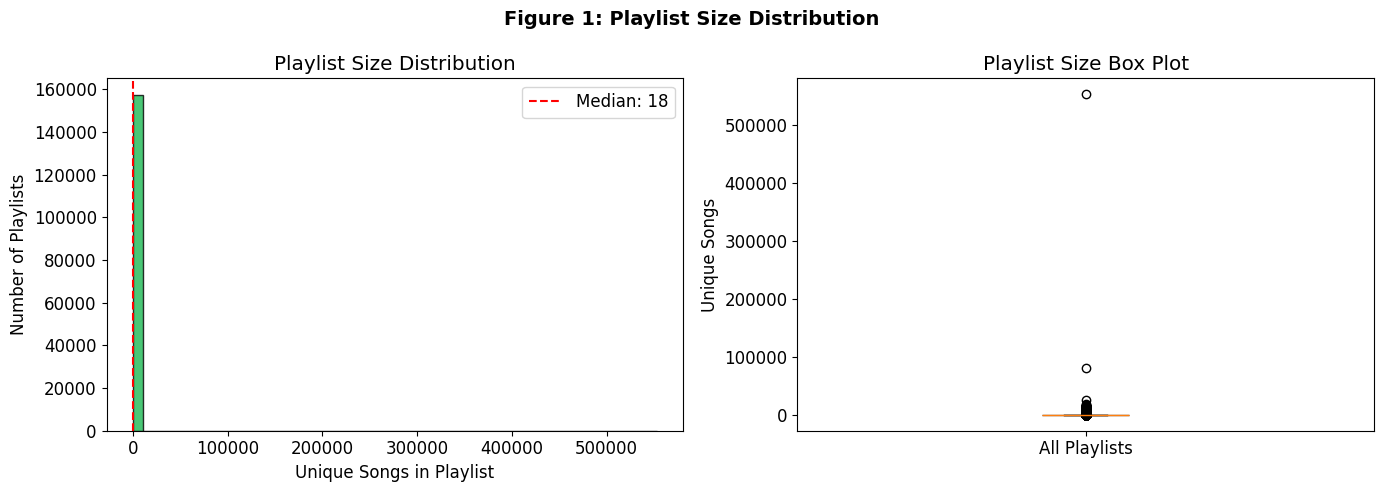

Mean: 70.0  |  Median: 18  |  Max: 553041


In [5]:
songs_per_playlist = df.groupby('playlistname')['song_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(songs_per_playlist, bins=50, color='#1DB954', edgecolor='black', alpha=0.8)
axes[0].axvline(songs_per_playlist.median(), color='red', linestyle='--',
                label=f'Median: {songs_per_playlist.median():.0f}')
axes[0].set_xlabel('Unique Songs in Playlist')
axes[0].set_ylabel('Number of Playlists')
axes[0].set_title('Playlist Size Distribution')
axes[0].legend()

axes[1].boxplot(songs_per_playlist, patch_artist=True,
                boxprops=dict(facecolor='#1DB954', alpha=0.7))
axes[1].set_ylabel('Unique Songs')
axes[1].set_title('Playlist Size Box Plot')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['All Playlists'])

plt.suptitle('Figure 1: Playlist Size Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_playlist_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean: {songs_per_playlist.mean():.1f}  |  Median: {songs_per_playlist.median():.0f}  |  Max: {songs_per_playlist.max()}')

## 3. EDA — Figure 2: Top Artists and Songs
Which artists and songs appear across the most playlists?

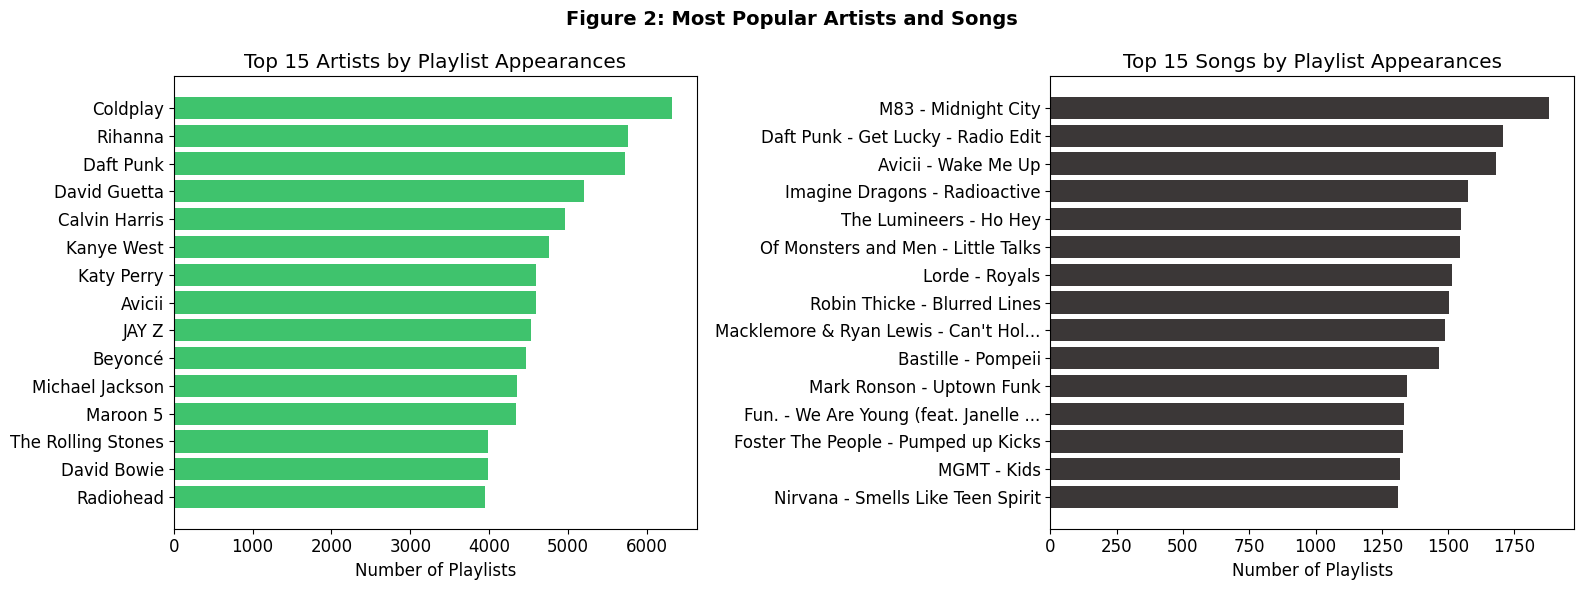

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_artists = (df.groupby('artistname')['playlistname']
                 .nunique().sort_values(ascending=False).head(15))
axes[0].barh(top_artists.index[::-1], top_artists.values[::-1],
             color='#1DB954', alpha=0.85)
axes[0].set_xlabel('Number of Playlists')
axes[0].set_title('Top 15 Artists by Playlist Appearances')

top_songs = (df.groupby('song_id')['playlistname']
               .nunique().sort_values(ascending=False).head(15))
short_names = [s[:35] + '...' if len(s) > 35 else s for s in top_songs.index]
axes[1].barh(short_names[::-1], top_songs.values[::-1],
             color='#191414', alpha=0.85)
axes[1].set_xlabel('Number of Playlists')
axes[1].set_title('Top 15 Songs by Playlist Appearances')

plt.suptitle('Figure 2: Most Popular Artists and Songs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_top_artists_songs.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Build Playlist-Song Matrix
Rows = playlists, Columns = songs, Values = 1 if the song is in that playlist.

Adjust the parameters below to control matrix size vs. computation time.

In [7]:
# --- PARAMETERS (tune these) ---
MIN_SONGS_PER_PLAYLIST = 20   # drop playlists smaller than this
MIN_PLAYLISTS_PER_SONG = 20   # drop songs appearing in fewer playlists
MAX_PLAYLISTS = 2500          # cap for speed — increase if you have more RAM
# --------------------------------

playlist_sizes = df.groupby('playlistname')['song_id'].nunique()
valid_playlists = playlist_sizes[playlist_sizes >= MIN_SONGS_PER_PLAYLIST].index
df2 = df[df['playlistname'].isin(valid_playlists)].copy()

song_counts = df2.groupby('song_id')['playlistname'].nunique()
valid_songs = song_counts[song_counts >= MIN_PLAYLISTS_PER_SONG].index
df2 = df2[df2['song_id'].isin(valid_songs)]

unique_pl = df2['playlistname'].unique()
if len(unique_pl) > MAX_PLAYLISTS:
    np.random.seed(42)
    sampled = np.random.choice(unique_pl, MAX_PLAYLISTS, replace=False)
    df2 = df2[df2['playlistname'].isin(sampled)]

pl_enc   = LabelEncoder()
song_enc = LabelEncoder()
df2['playlist_idx'] = pl_enc.fit_transform(df2['playlistname'])
df2['song_idx']     = song_enc.fit_transform(df2['song_id'])

N_PL   = df2['playlist_idx'].nunique()
N_SONG = df2['song_idx'].nunique()
density = df2.shape[0] / (N_PL * N_SONG) * 100

print(f'Matrix: {N_PL} playlists x {N_SONG} songs')
print(f'Non-zero entries: {df2.shape[0]:,}')
print(f'Density: {density:.3f}%')

Matrix: 2500 playlists x 55725 songs
Non-zero entries: 188,985
Density: 0.136%


## 5. EDA — Figure 3: Matrix Sparsity
Visualising the sparsity of the playlist-song matrix. Each dot is a song present in a playlist.
The vast white space is what SVD learns to fill in.

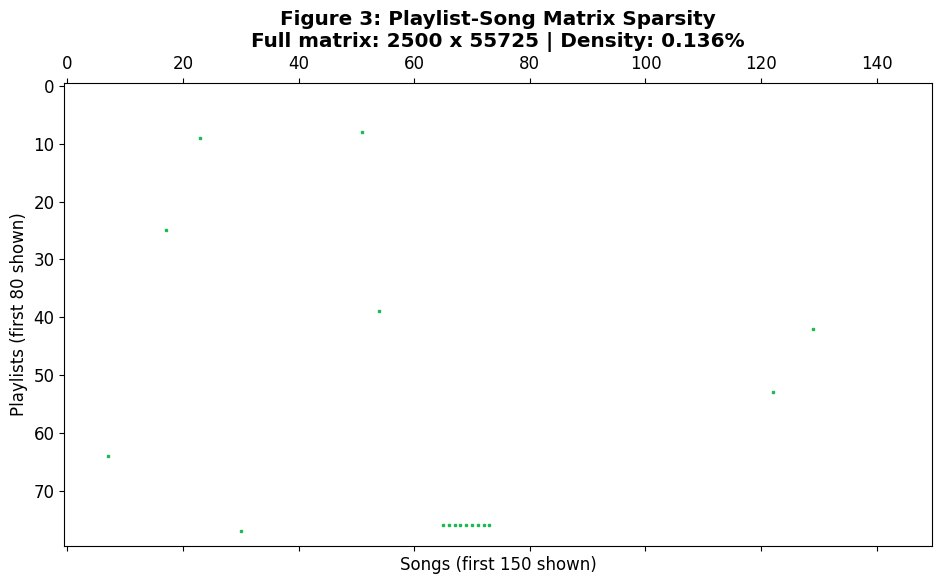

In [8]:
SHOW_PL   = 80
SHOW_SONG = 150

sub = df2[(df2['playlist_idx'] < SHOW_PL) & (df2['song_idx'] < SHOW_SONG)]
mat = np.zeros((SHOW_PL, SHOW_SONG))
for _, row in sub.iterrows():
    mat[int(row['playlist_idx']), int(row['song_idx'])] = 1

fig, ax = plt.subplots(figsize=(14, 6))
ax.spy(mat, markersize=2, color='#1DB954')
ax.set_xlabel(f'Songs (first {SHOW_SONG} shown)')
ax.set_ylabel(f'Playlists (first {SHOW_PL} shown)')
ax.set_title(
    f'Figure 3: Playlist-Song Matrix Sparsity\n'
    f'Full matrix: {N_PL} x {N_SONG} | Density: {density:.3f}%',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig3_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train / Test Split (80/20 within each playlist)

In [9]:
np.random.seed(42)
HOLDOUT = 0.2

train_rows, train_cols = [], []
test_entries = {}   # playlist_idx -> array of held-out song indices

for pl_idx, grp in df2.groupby('playlist_idx'):
    songs = grp['song_idx'].values
    n_hold = max(1, int(len(songs) * HOLDOUT))
    held   = np.random.choice(songs, n_hold, replace=False)
    kept   = np.setdiff1d(songs, held)
    test_entries[pl_idx] = held
    for s in kept:
        train_rows.append(pl_idx)
        train_cols.append(s)

train_matrix = csr_matrix(
    (np.ones(len(train_rows)), (train_rows, train_cols)),
    shape=(N_PL, N_SONG)
)

print(f'Training entries:          {len(train_rows):,}')
print(f'Test playlists:            {len(test_entries):,}')
avg_held = np.mean([len(v) for v in test_entries.values()])
print(f'Avg held-out songs/playlist: {avg_held:.1f}')

Training entries:          135,462
Test playlists:            2,500
Avg held-out songs/playlist: 14.8


## 7. Apply SVD & Reconstruct
Decompose the training matrix into U (playlists), Sigma (importance), Vt (songs).
Multiply them back together to get predicted scores for every playlist-song pair.

In [10]:
K = 50  # number of latent factors — tune this!

print(f'Running SVD with k={K}...')
U, sigma, Vt = svds(train_matrix.astype(float), k=K)

# svds returns ascending order — reverse to descending
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]

predicted = np.dot(U, np.dot(np.diag(sigma), Vt))

print(f'U shape    (playlists x k): {U.shape}')
print(f'Sigma shape          (k,):  {sigma.shape}')
print(f'Vt shape   (k x songs):     {Vt.shape}')
print(f'Reconstructed matrix:       {predicted.shape}')
print(f'Score range: [{predicted.min():.3f}, {predicted.max():.3f}]')

Running SVD with k=50...
U shape    (playlists x k): (2500, 50)
Sigma shape          (k,):  (50,)
Vt shape   (k x songs):     (50, 55725)
Reconstructed matrix:       (2500, 55725)
Score range: [-0.337, 1.654]


## 8. SVD Figure — Singular Values & Explained Variance
A steep drop-off means the first few latent factors capture most of the structure.
Use this to justify your chosen k.

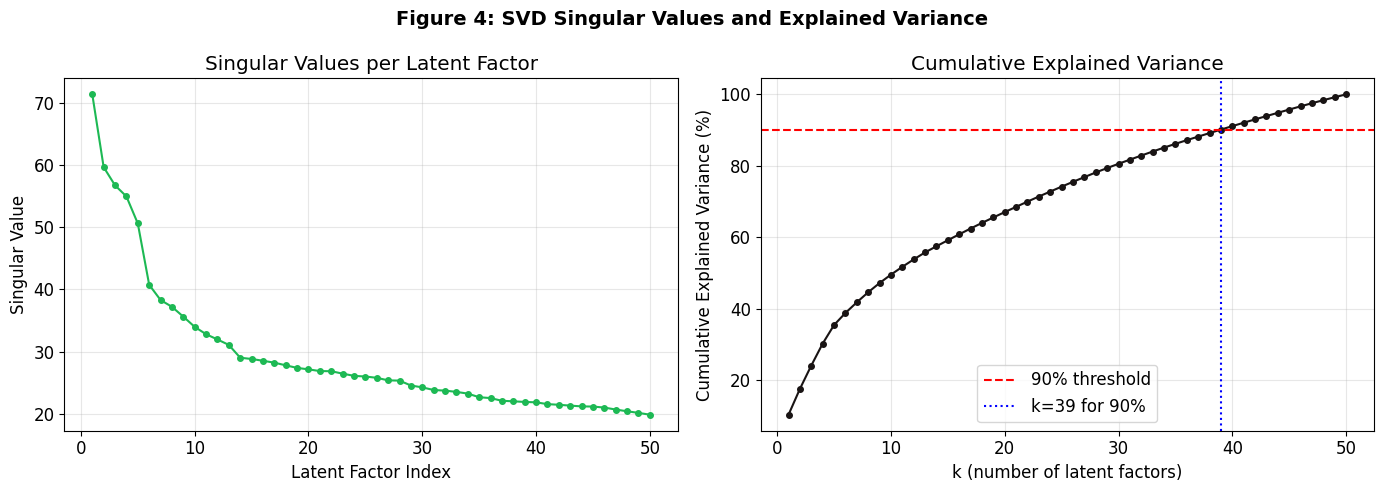

k=39 factors needed to explain 90% of variance


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(sigma)+1), sigma, 'o-', color='#1DB954', markersize=4)
axes[0].set_xlabel('Latent Factor Index')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('Singular Values per Latent Factor')
axes[0].grid(True, alpha=0.3)

exp_var = np.cumsum(sigma**2) / np.sum(sigma**2) * 100
axes[1].plot(range(1, len(sigma)+1), exp_var, 'o-', color='#191414', markersize=4)
axes[1].axhline(90, color='red', linestyle='--', label='90% threshold')
k90 = int(np.argmax(exp_var >= 90)) + 1
axes[1].axvline(k90, color='blue', linestyle=':', label=f'k={k90} for 90%')
axes[1].set_xlabel('k (number of latent factors)')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 4: SVD Singular Values and Explained Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_singular_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'k={k90} factors needed to explain 90% of variance')

## 9. Recommendation Function

In [12]:
def recommend(pl_idx, predicted, train_matrix, song_enc, k=10):
    scores = predicted[pl_idx].copy()
    already = train_matrix[pl_idx].nonzero()[1]
    scores[already] = -np.inf
    top_idx = np.argsort(scores)[::-1][:k]
    return list(zip(song_enc.inverse_transform(top_idx), scores[top_idx]))

# Demo
demo_idx  = 0
demo_name = pl_enc.inverse_transform([demo_idx])[0]
existing  = song_enc.inverse_transform(train_matrix[demo_idx].nonzero()[1])

print(f'Playlist: "{demo_name}"')
print(f'\nSongs in playlist (first 10 of {len(existing)}):')
for s in existing[:10]:
    print(f'  - {s}')

print(f'\nTop 10 SVD Recommendations:')
for i, (song, score) in enumerate(recommend(demo_idx, predicted, train_matrix, song_enc), 1):
    print(f'  {i:>2}. {song}  (score: {score:.4f})')

Playlist: " Konstmusik"

Songs in playlist (first 10 of 4):
  - Arvo Pärt - Spiegel im spiegel
  - Nikolaus Harnoncourt - Mozart : Requiem in D minor K626 : I Requiem
  - Stevie Wonder - We Can Work It Out
  - U2 - When Love Comes To Town

Top 10 SVD Recommendations:
   1. Bon Jovi - Livin' On A Prayer  (score: 0.0007)
   2. U2 - With Or Without You  (score: 0.0007)
   3. Bon Jovi - Wanted Dead Or Alive  (score: 0.0006)
   4. U2 - In A Little While  (score: 0.0006)
   5. The Killers - Uncle Jonny  (score: 0.0006)
   6. Nirvana - Lounge Act  (score: 0.0006)
   7. Nirvana - Stay Away  (score: 0.0006)
   8. Oasis - Cigarettes & Alcohol  (score: 0.0006)
   9. Muse - Sing For Absolution  (score: 0.0006)
  10. Franz Ferdinand - You Could Have It So Much Better  (score: 0.0006)


## 10. Evaluation — Precision@k, Recall@k, F1@k
For each test playlist: recommend top-k songs, check how many held-out songs appear in them.

In [13]:
def precision_at_k(ranked, holdout, k):
    return len(set(ranked[:k]) & set(holdout)) / k

def recall_at_k(ranked, holdout, k):
    if len(holdout) == 0:
        return 0.0
    return len(set(ranked[:k]) & set(holdout)) / len(holdout)

def f1_at_k(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

K_VALUES = [1, 5, 10, 20, 50]
results  = {k: {'p': [], 'r': [], 'f1': []} for k in K_VALUES}

for pl_idx, holdout in test_entries.items():
    if len(holdout) == 0:
        continue
    scores = predicted[pl_idx].copy()
    scores[train_matrix[pl_idx].nonzero()[1]] = -np.inf
    ranked = np.argsort(scores)[::-1]
    for k in K_VALUES:
        p  = precision_at_k(ranked, holdout, k)
        r  = recall_at_k(ranked, holdout, k)
        results[k]['p'].append(p)
        results[k]['r'].append(r)
        results[k]['f1'].append(f1_at_k(p, r))

print(f'{"k":>5} | {"Precision@k":>12} | {"Recall@k":>10} | {"F1@k":>8}')
print('-' * 46)
for k in K_VALUES:
    p  = np.mean(results[k]['p'])
    r  = np.mean(results[k]['r'])
    f  = np.mean(results[k]['f1'])
    print(f'{k:>5} | {p:>12.4f} | {r:>10.4f} | {f:>8.4f}')

    k |  Precision@k |   Recall@k |     F1@k
----------------------------------------------
    1 |       0.0452 |     0.0041 |   0.0068
    5 |       0.0329 |     0.0127 |   0.0144
   10 |       0.0256 |     0.0187 |   0.0162
   20 |       0.0197 |     0.0296 |   0.0174
   50 |       0.0143 |     0.0506 |   0.0166


## 11. Evaluation Figure — Precision, Recall, F1 Curves

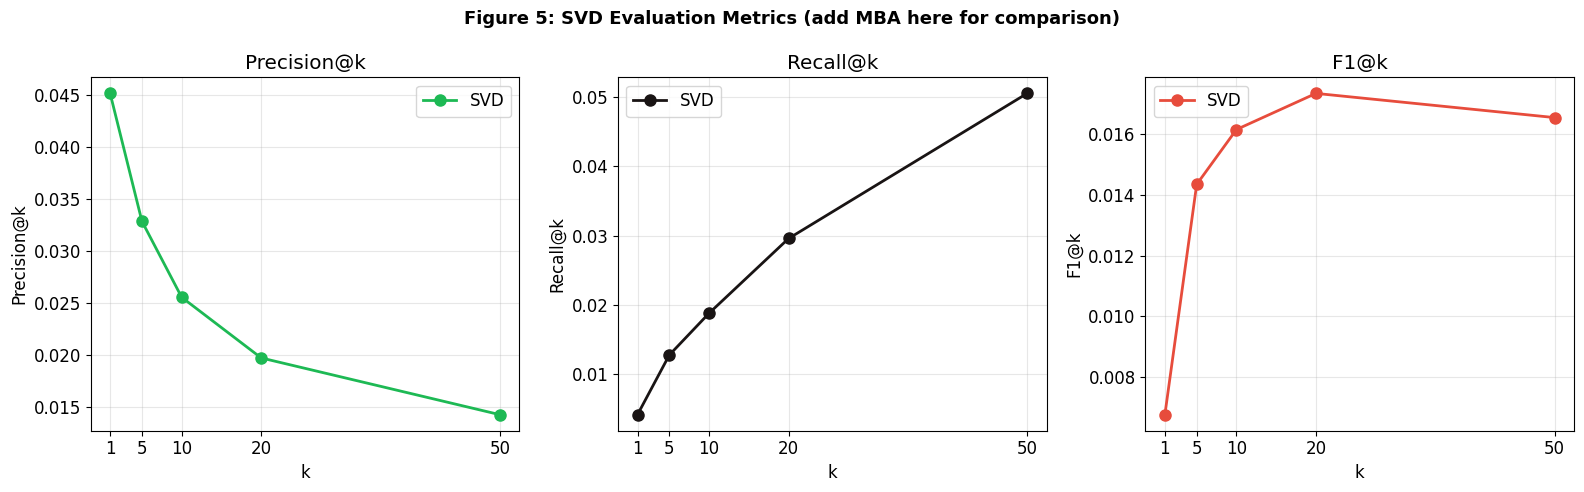

In [14]:
avg_p  = [np.mean(results[k]['p'])  for k in K_VALUES]
avg_r  = [np.mean(results[k]['r'])  for k in K_VALUES]
avg_f1 = [np.mean(results[k]['f1']) for k in K_VALUES]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, vals, label, color in zip(
    axes,
    [avg_p, avg_r, avg_f1],
    ['Precision@k', 'Recall@k', 'F1@k'],
    ['#1DB954', '#191414', '#e74c3c']
):
    ax.plot(K_VALUES, vals, 'o-', color=color, linewidth=2, markersize=8, label='SVD')
    ax.set_xlabel('k')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(K_VALUES)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Figure 5: SVD Evaluation Metrics (add MBA here for comparison)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Latent Space — Figure 6
Project the top 200 most popular songs into 2D using the first two right singular vectors.
Songs that appear together often in playlists should cluster together.

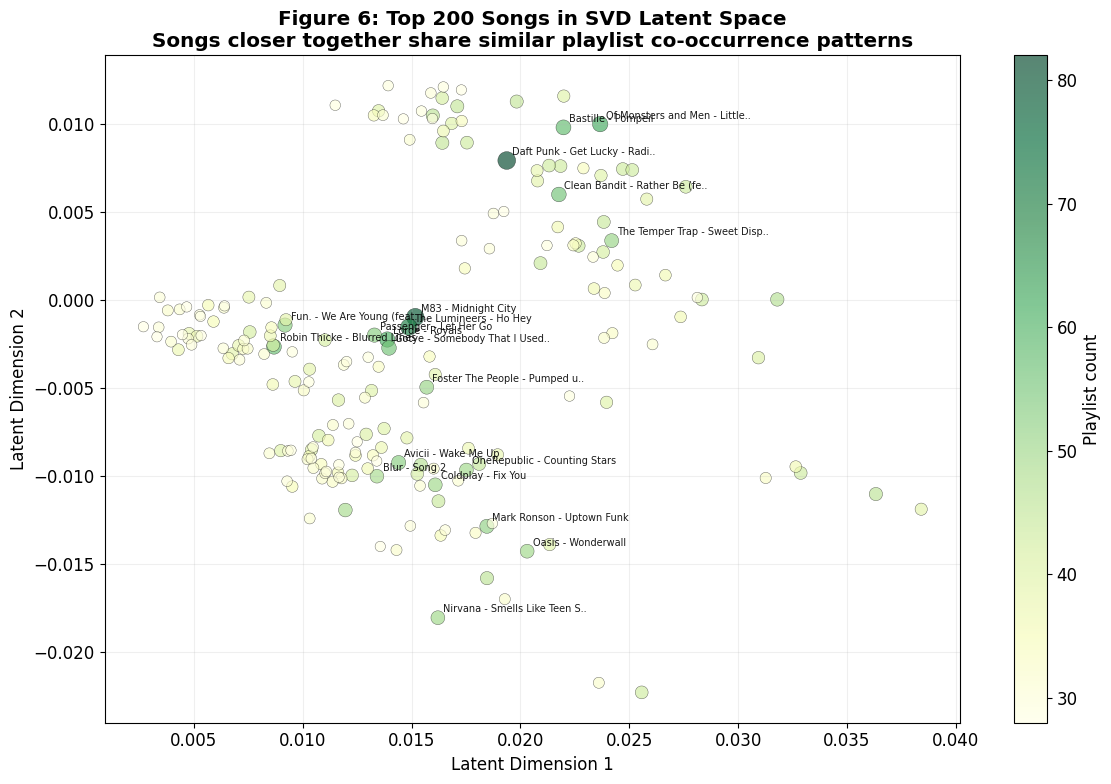

In [15]:
song_latent = Vt[:2, :].T          # shape (n_songs, 2)
song_pop    = df2.groupby('song_idx')['playlist_idx'].nunique()

top200_idx  = song_pop.nlargest(200).index.values
top200_name = song_enc.inverse_transform(top200_idx)
top200_xy   = song_latent[top200_idx]
top200_pop  = song_pop[top200_idx].values

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(top200_xy[:, 0], top200_xy[:, 1],
                s=top200_pop * 2, c=top200_pop,
                cmap='YlGn', alpha=0.65,
                edgecolors='black', linewidths=0.3)
plt.colorbar(sc, label='Playlist count')

# Label top 20
top20_idx  = song_pop.nlargest(20).index.values
top20_name = song_enc.inverse_transform(top20_idx)
top20_xy   = song_latent[top20_idx]
for name, (x, y) in zip(top20_name, top20_xy):
    short = name[:28] + '..' if len(name) > 28 else name
    ax.annotate(short, (x, y), fontsize=7, alpha=0.9,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title(
    'Figure 6: Top 200 Songs in SVD Latent Space\n'
    'Songs closer together share similar playlist co-occurrence patterns',
    fontweight='bold'
)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig6_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Hyperparameter — Effect of k on Performance
How does the number of latent factors affect recommendation quality?
This justifies the k you chose in Section 7.

k=   5  P@10=0.0058  R@10=0.0032
k=  10  P@10=0.0083  R@10=0.0047
k=  20  P@10=0.0142  R@10=0.0093
k=  50  P@10=0.0256  R@10=0.0187
k= 100  P@10=0.0363  R@10=0.0280


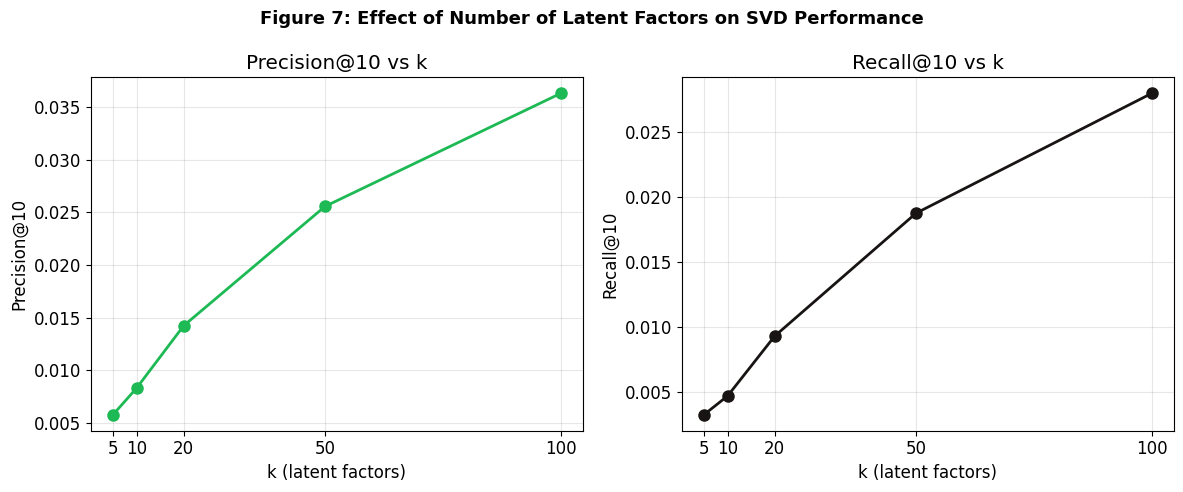

In [16]:
K_SWEEP  = [5, 10, 20, 50, 100]
EVAL_AT  = 10

sweep_p, sweep_r = [], []

for k_val in K_SWEEP:
    U_k, s_k, Vt_k = svds(train_matrix.astype(float), k=k_val)
    pred_k = np.dot(U_k, np.dot(np.diag(s_k), Vt_k))
    ps, rs = [], []
    for pl_idx, holdout in test_entries.items():
        if len(holdout) == 0:
            continue
        sc = pred_k[pl_idx].copy()
        sc[train_matrix[pl_idx].nonzero()[1]] = -np.inf
        ranked = np.argsort(sc)[::-1]
        ps.append(precision_at_k(ranked, holdout, EVAL_AT))
        rs.append(recall_at_k(ranked, holdout, EVAL_AT))
    sweep_p.append(np.mean(ps))
    sweep_r.append(np.mean(rs))
    print(f'k={k_val:>4}  P@{EVAL_AT}={np.mean(ps):.4f}  R@{EVAL_AT}={np.mean(rs):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(K_SWEEP, sweep_p, 'o-', color='#1DB954', linewidth=2, markersize=8)
axes[0].set_xlabel('k (latent factors)')
axes[0].set_ylabel(f'Precision@{EVAL_AT}')
axes[0].set_title(f'Precision@{EVAL_AT} vs k')
axes[0].set_xticks(K_SWEEP)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_SWEEP, sweep_r, 'o-', color='#191414', linewidth=2, markersize=8)
axes[1].set_xlabel('k (latent factors)')
axes[1].set_ylabel(f'Recall@{EVAL_AT}')
axes[1].set_title(f'Recall@{EVAL_AT} vs k')
axes[1].set_xticks(K_SWEEP)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 7: Effect of Number of Latent Factors on SVD Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of Figures

| Figure | Description |
|--------|-------------|
| Fig 1 | Playlist size distribution — EDA |
| Fig 2 | Top artists and songs — EDA |
| Fig 3 | Matrix sparsity — motivates SVD |
| Fig 4 | Singular values and explained variance — justifies k |
| Fig 5 | Precision/Recall/F1 curves — **main results** (add MBA here) |
| Fig 6 | Songs in latent space — interprets what SVD learned |
| Fig 7 | k sweep — hyperparameter analysis |

**Next step:** run your MBA notebook and add its Precision@k / Recall@k to Fig 5 for a direct comparison.